<a href="https://colab.research.google.com/github/henrykibithia8-dev/Data-lab-projects/blob/main/Predicting_Housing_Prices_in_Buenos_Aires_Project!.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [144]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import VimeoVideo
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.utils.validation import check_is_fitted
from sklearn.model_selection import train_test_split

warnings.simplefilter(action="ignore", category=FutureWarning)

###automate the data importing and cleaning process is by writing a function. This will make sure that all our data undergoes the same process, and that our analysis is easily reproducible — something that's very important in science in general and data science in particular.

In [145]:
#creating a function
def wrangle(filepath):
  #read csv files
  df = pd.read_csv(filepath)
  #subset for properties in "Capital Federal"
  mask_ba = df["place_with_parent_names"].str.contains("Capital Federal") #properties in "Capital Federal"
  #subset for "apartment" properties
  mask_apt = df["property_type"] == "apartment"
  #subset for price less than 400,000
  mask_price = df["price_aprox_usd"] < 400000

  # Apply initial masks
  df = df[mask_ba & mask_apt & mask_price]

  #subset Remove outliers for area "surface_covered_in_m2"
  low_q, high_q = df["surface_covered_in_m2"].quantile([0.1, 0.9])
  mask_area = df["surface_covered_in_m2"].between(low_q, high_q)
  df = df[mask_area]

  return df

In [146]:
#importing csv file
df = wrangle("/content/buenos-aires-real-estate-1.csv")
df["property_type"].unique()

array(['apartment'], dtype=object)

In [147]:
#check the number of row
assert(len(df)<= 8606)

###Task 2.1.3: Add to your wrangle function so that the DataFrame it returns only includes apartments in Buenos Aires ("Capital Federal") that cost less than $400,000 USD. Then recreate df from data/buenos-aires-real-estate-1.csv by re-running the cells above.

In [148]:
df["property_type"].unique()

array(['apartment'], dtype=object)

We saw in the previous project that property size is an important factor in determining price. With that in mind, let's look at the distribution of apartment sizes in our dataset.


Task 2.1.4: Create a histogram of "surface_covered_in_m2". Make sure that the x-axis has the label "Area [sq meters]" and the plot has the title "Distribution of Apartment Sizes".




In [149]:
#view our columns
df.columns

Index(['operation', 'property_type', 'place_with_parent_names', 'lat-lon',
       'price', 'currency', 'price_aprox_local_currency', 'price_aprox_usd',
       'surface_total_in_m2', 'surface_covered_in_m2', 'price_usd_per_m2',
       'price_per_m2', 'floor', 'rooms', 'expenses', 'properati_url'],
      dtype='object')

In [150]:
df.describe()["surface_covered_in_m2"]


,surface_covered_in_m2
count,1343.000000
mean,55.076694
std,18.160427
min,31.000000
25%,40.000000
50%,50.000000
75%,68.500000
max,100.000000


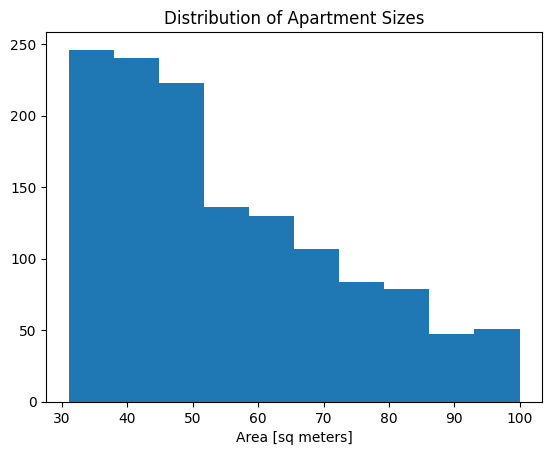

In [151]:
#histogram of area without outliers
plt.hist(df["surface_covered_in_m2"])
plt.xlabel("Area [sq meters]")
plt.title("Distribution of Apartment Sizes")
plt.show()

###Task 2.1.6: Add to your wrangle function so that it removes observations that are outliers in the "surface_covered_in_m2" column. Specifically, all observations should fall between the 0.1 and 0.9 quantiles for "surface_covered_in_m2".

In [152]:

#create a subset for quantiles
low_q, high_q = df["surface_covered_in_m2"].quantile([0.1, 0.9])
mask_area = df["surface_covered_in_m2"].between(low_q, high_q)
mask_area

,surface_covered_in_m2
4,True
9,True
29,True
40,True
41,True
...,...
8589,True
8590,True
8593,True
8601,True


In [153]:
assert(len(df)<= 1343)

###Now that our dataset is free of outliers, it's time to start exploring the relationship between apartment size and price. Let's use one of the tools we learned in the last project.

In [154]:
df.head(1)

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...


In [155]:
df["surface_total_in_m2"].corr(df["price_aprox_usd"])

np.float64(0.5826596820003203)

###Create a scatter plot that shows price ("price_aprox_usd") vs area ("surface_covered_in_m2") in our dataset. Make sure to label your x-axis "Area [sq meters]" and your y-axis "Price [USD]".

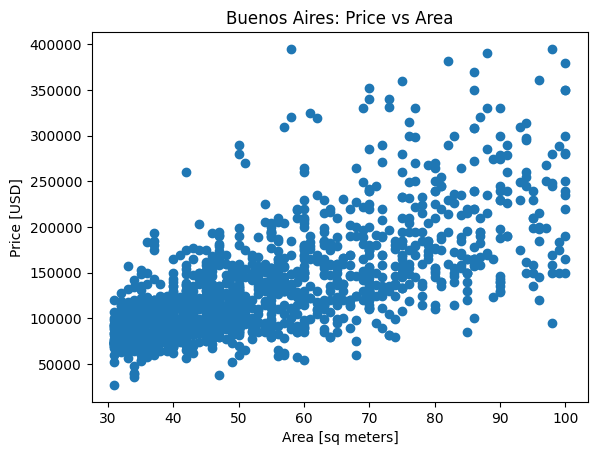

In [156]:
#scatterplot to compare rlship between size and price
plt.scatter(x=df["surface_covered_in_m2"], y = df["price_aprox_usd"])
plt.xlabel("Area [sq meters]")
plt.ylabel("Price [USD]")
plt.title("Buenos Aires: Price vs Area")
plt.show()

####INTRODUCTION

####TO

####LINNEAR MODEL

###SPLIT

A key part in any model-building project is separating your target (the thing you want to predict) from your features (the information your model will use to make its predictions). Since this is our first model, we'll use just one feature: apartment size.

Task 2.1.8: Create the feature matrix named X_train, which you'll use to train your model. It should contain one feature only: ["surface_covered_in_m2"]. Remember that your feature matrix should always be two-dimensional.

In [157]:
from re import X
feature = ["surface_covered_in_m2"]
X_train = df[feature]
X_train

,surface_covered_in_m2
4,70.0
9,42.0
29,54.0
40,42.0
41,50.0
...,...
8589,42.0
8590,41.0
8593,43.0
8601,70.0


###Now that we have a features, the next step is to create a target. (By the way, you may have noticed that we're adding a _train tag to the variable names for our feature matrix and target vector. This is to remind us that this is the data we'll use to train our model, and not the data we'll use to test it.)

Create the target vector named y_train, which you'll use to train your model. Your target should be "price_aprox_usd". Remember that, in most cases, your target vector should be one-dimensional.

In [158]:
target = "price_aprox_usd"
y_train = df[target]
y_train

,price_aprox_usd
4,129000.00
9,87000.00
29,118000.00
40,57000.00
41,90000.00
...,...
8589,73536.95
8590,119000.00
8593,62000.00
8601,125000.00


In [159]:
y_mean = y_train.mean() #one prediction that our dumb model will always make
y_mean

np.float64(135527.83871928515)

Now that we have the one prediction (y_mean) that our dumb model will always make, we need to generate a list that repeats the prediction for every observation in our dataset.

In [160]:
#to get "y_pred_baseline", we multiply a list of [y_mean] by len(y_train)
y_pred_baseline = [y_mean] * len(y_train)
# need to generate a list that repeats the prediction for every observation in our dataset.
y_pred_baseline[:5] #1st five

[np.float64(135527.83871928515),
 np.float64(135527.83871928515),
 np.float64(135527.83871928515),
 np.float64(135527.83871928515),
 np.float64(135527.83871928515)]

So how does our baseline model perform? One way to evaluate it is by plotting it on top of the scatter plot we made above.

##Task 2.1.12: Add a line to the plot below that shows the relationship between the observations X_train and our dumb model's predictions y_pred_baseline. Be sure that the line color is orange, and that it has the label "Baseline Model".

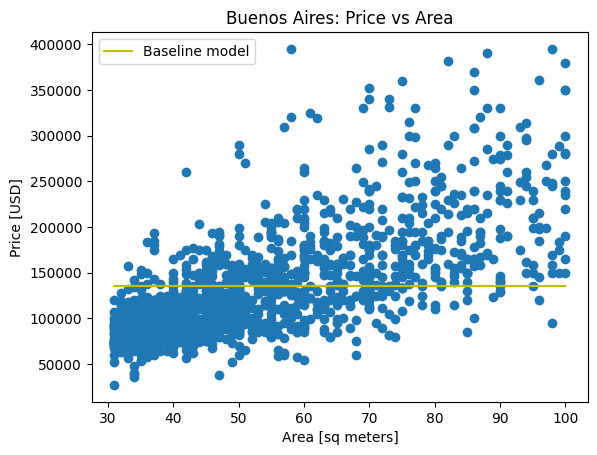

In [161]:
plt.plot(X_train, y_pred_baseline, c = "y", label = "Baseline model")
plt.scatter(X_train, y_train)
plt.xlabel("Area [sq meters]")
plt.ylabel("Price [USD]")
plt.title("Buenos Aires: Price vs Area")
plt.legend();

###The Naive model above tells us that no matter the size of the house, the price remains constant


###Looking at this visualization, it seems like our baseline model doesn't really follow the trend in the data. But, as a data scientist, you can't depend only on a subjective plot to evaluate a model. You need an exact, mathematically calculate performance metric. There are lots of performance metrics, but the one we'll use here is the mean absolute error.

***MAE = Sum(true y values - y prediction values) / n of data point***

In [162]:
#lets calulate the mean absolute error
baseline_MAE = mean_absolute_error(y_train, y_pred_baseline) #python with do division and subtraction

print("Mean of house prices:", round(y_mean, 2)) #mean prices
print("Mean absolute error:", round(baseline_MAE, 2)) #mean absolute error



Mean of house prices: 135527.84
Mean absolute error: 45199.46


##What does this information tell us? If we always predicted that an apartment price is 135,527.84  our  predictions  would  be  off  by  an  average  of 45,199.46. It also tells us that our model needs to have mean absolute error below $45,199.46 in order to be useful.

###Iterate

The next step in building a model is iterating. This involves building a model, training it, evaluating it, and then repeating the process until you're happy with the model's performance. Even though the model we're building is linear, the iteration process rarely follows a straight line. Be prepared for trying new things, hitting dead-ends, and waiting around while your computer does long computations to train your model. ☕️ Let's get started!
The first thing we need to do is create our model — in this case, one that uses linear regression.

In [163]:
from sklearn import linear_model
#Step 1, Instaciate or create a model
model = LinearRegression()

In [164]:
#confirm if model is created
assert isinstance(model, LinearRegression)

The second thing we need to do is use our data to train our model. Another way to say this is fit our model to the training data.

In [165]:
#Task 2.1.15: Fit your model to the data, X_train and y_train
model.fit(X_train, y_train)

LinearRegression()

In [166]:
# Check your work
check_is_fitted(model)

#Evaluate

The final step is to evaluate our model. In order to do that, we'll start by seeing how well it performs when making predictions for data that it saw during training. So let's have it predict the price for the houses in our training set.

In [167]:
#lets make predictions for the 1st 5 using X_train
y_pred_training = model.predict(X_train)
y_pred_training[:5]

array([169151.87330223, 106064.44707446, 133101.91545779, 106064.44707446,
       124089.42599668])

In [168]:
#cofirm
assert(len(y_pred_training) == 1343)

Task 2.1.13: Calculate the baseline mean absolute error for your predictions in y_pred_baseline as compared to the true targets in y.

In [169]:
training_MAE = mean_absolute_error(y_train, y_pred_training) #MAE for true values
print("mean absolute error for true values:", round(training_MAE,2))


mean absolute error for true values: 31248.26


Our model beat the baseline by over $10,000! That's a good indicator that it will be helpful in predicting apartment prices. But the real test is how the model performs on data that it hasn't seen before, data that we call the test set. In the future, you'll create your own test set before you train your model, but here we'll use one that's pre-made, and we'll evaluate the model using the WQU auto-grader.

#Task 2.1.18: Run the code below to import your test data buenos-aires-test-features.csv into a DataFrame and generate a Series of predictions using your model. After the code runs successfully, click the Check Activity button on the left pane to verify your predictions.

In [170]:
df_test = pd.read_csv("/content/buenos-aires-real-estate-1.csv")